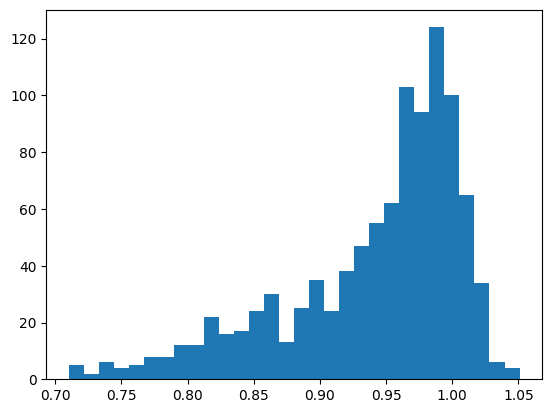

In [ ]:
import numpy as np  
import matplotlib.pyplot as plt 
import random
import sklearn 
from random import sample
from sklearn.neighbors import KernelDensity
import scipy

sigma=0.02
mu=1

chi=np.random.uniform(0,1,1000)
M=np.random.normal(mu,sigma,1000)

def f(X): 
    return np.sqrt((1+np.sqrt(1-X**2))/2)

M_irr=M*f(chi)
plt.hist(M_irr,30)
plt.show()
  

Using KDE

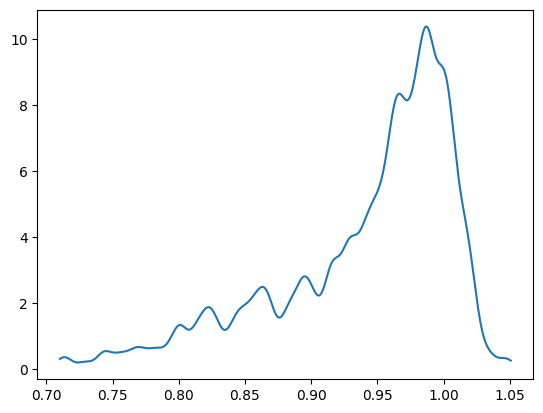

In [ ]:
xgrid = np.linspace(M_irr.min(),M_irr.max(),1000) #x of KDE 

def kde_sklearn(data, bandwidth = 1.0, kernel="linear"):

    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

PDFGaussian = kde_sklearn(M_irr,bandwidth=0.005,kernel="gaussian")  
plt.plot(xgrid,PDFGaussian)

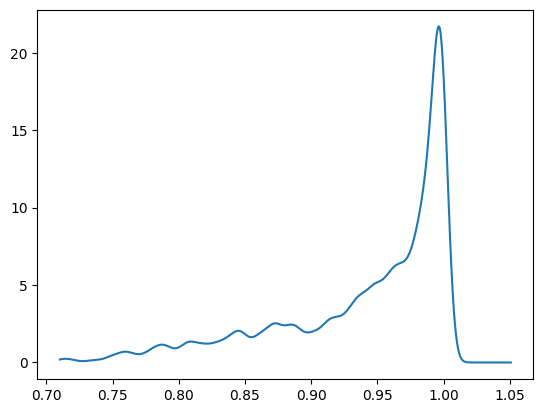

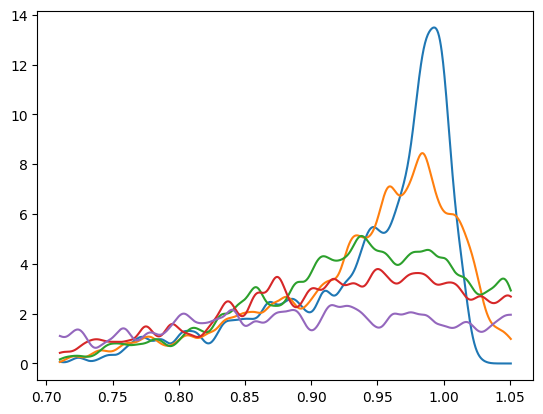

Text(0, 0.5, 'ks Result')

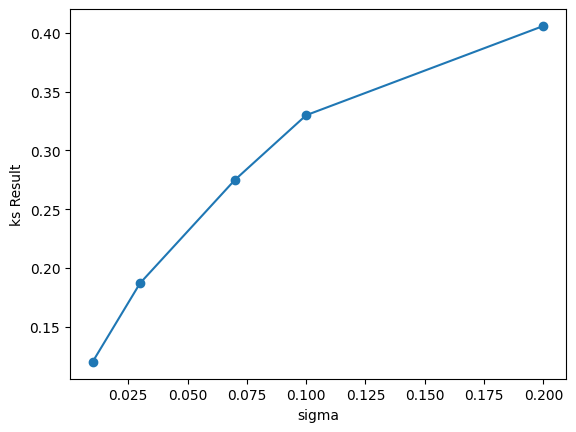

In [106]:
ks1=[]
PDFChi = kde_sklearn(f(chi),bandwidth=0.005,kernel="gaussian") 
plt.plot(xgrid,PDFChi)
plt.show()
sigmas=[0.01,0.03,0.07,0.1,0.2]
for i in sigmas:
    Mk=np.random.normal(mu,i,1000)
    Mk_irr=Mk*f(chi)
    PDFGaussian = kde_sklearn(Mk_irr,bandwidth=0.005,kernel="gaussian")  
    plt.plot(xgrid,PDFGaussian)
    ks1.append(scipy.stats.ks_2samp(Mk_irr,f(chi)).statistic)

plt.show()
plt.scatter(sigmas,ks1)
plt.plot(sigmas,ks1)
plt.xlabel("sigma")
plt.ylabel("ks Result")


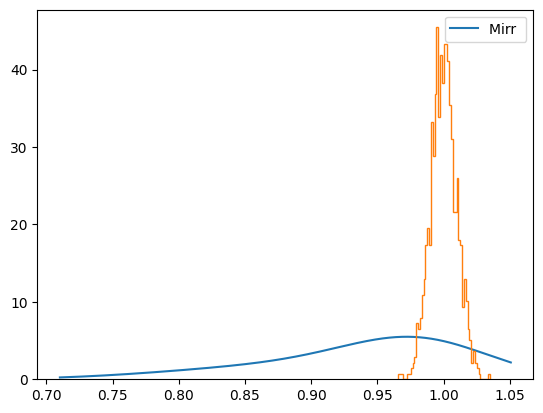

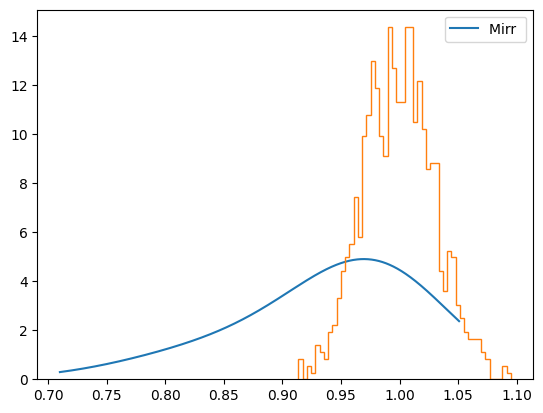

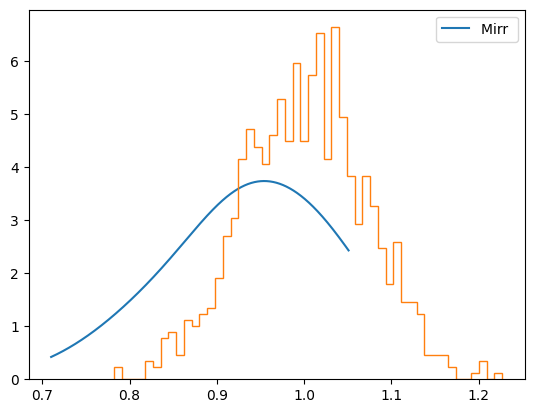

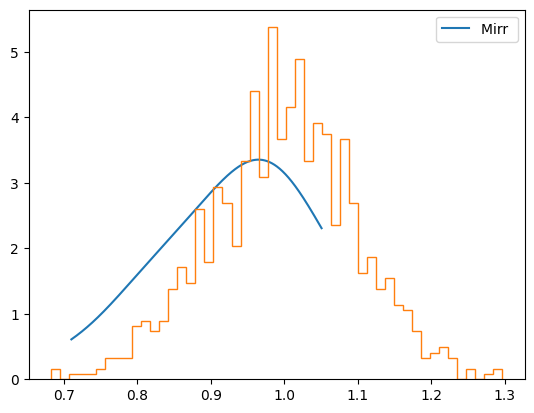

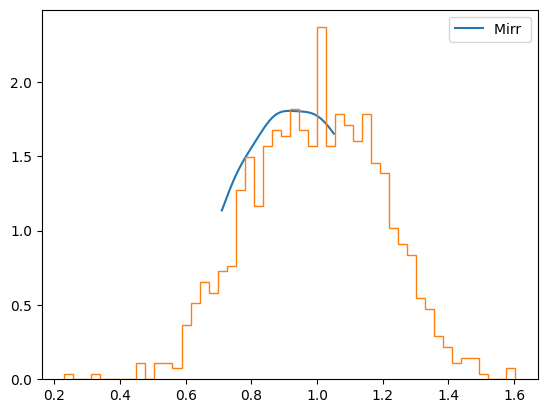

[np.float64(0.618),
 np.float64(0.428),
 np.float64(0.284),
 np.float64(0.219),
 np.float64(0.122)]

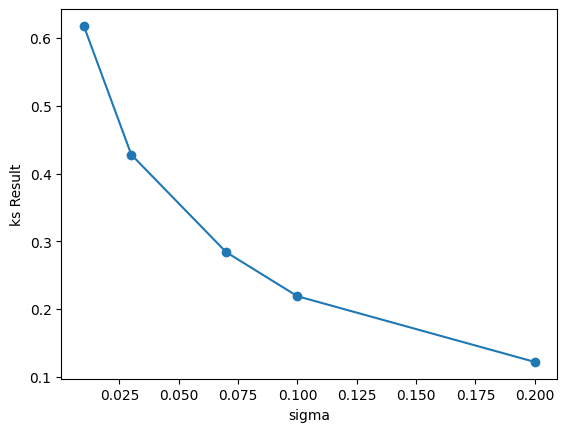

In [ ]:
ks2=[] #ks between Mirr and M

for i in sigmas:
    Mks=np.random.normal(mu,i,1000) #first distrib (gaussian with different sigma)
    Mk_irrr=Mks*f(chi) #second distrib 

    PDFMirr = kde_sklearn(Mk_irrr,bandwidth=0.05,kernel="gaussian")  
    gaussy = kde_sklearn(Mks,bandwidth=0.05,kernel="gaussian")
    gaussy = kde_sklearn(Mks,bandwidth=0.05,kernel="gaussian")
    plt.plot(xgrid,PDFMirr, label="Mirr ")
    plt.hist(Mks, bins=50, density=True, histtype="step")
    #plt.xlim(0.5,1.5)
    plt.legend()
    plt.show()
    ks2.append(scipy.stats.ks_2samp(Mk_irrr,Mks).statistic)

plt.show()
plt.scatter(sigmas,ks2)
plt.plot(sigmas,ks2)
plt.xlabel("sigma")
plt.ylabel("ks Result")
ks2